# Simulation Guide — Full Walkthrough

This notebook walks through a complete quantum network simulation, covering every layer from physical to application, plus the centralized clock, configuration and metrics.

## Imports

In [1]:
import sys
sys.path.append('../')

from quantumnet.topology import Network, Host
from quantumnet.quantum import Qubit, Epr
from quantumnet.runtime import Clock
from quantumnet.config import SimulationConfig
from quantumnet.control import Controller
from quantumnet.utils import Logger

Logger.get_instance().activate()

---
## 1. Configuration

`SimulationConfig` centralizes all simulation parameters. You can use defaults, load from YAML, or override programmatically.

In [2]:
config = SimulationConfig()
print("Decoherence per timeslot:", config.decoherence.per_timeslot)
print("Decoherence per measurement:", config.decoherence.per_measurement)
print("EPR fidelity threshold:", config.fidelity.epr_threshold)
print("Purification threshold:", config.fidelity.purification_threshold)
print("Link max attempts:", config.protocol.link_max_attempts)
print("Transport max attempts:", config.protocol.transport_max_attempts)
print("Qubits per host:", config.defaults.qubits_per_host)
print("EPRs per channel:", config.defaults.eprs_per_channel)

Decoherence per timeslot: 0.9
Decoherence per measurement: 0.99
EPR fidelity threshold: 0.8
Purification threshold: 0.8
Link max attempts: 2
Transport max attempts: 2
Qubits per host: 10
EPRs per channel: 10


## 2. Clock

The `Clock` tracks timeslots, fires callbacks on each tick, and records events in a history log.

In [3]:
clock = Clock()
print(f"Initial timeslot: {clock.now}")

# Register a tick callback
clock.on_tick(lambda c: print(f"  [tick] timeslot = {c.now}"))

# Register an event callback
clock.on('my_event', lambda c, **d: print(f"  [event] my_event at t={c.now}, data={d}"))

clock.tick()
clock.emit('my_event', info='hello')
clock.tick(cost=2)

print(f"\nFinal timeslot: {clock.now}")
print(f"History: {clock.history}")

Initial timeslot: 0
  [tick] timeslot = 1
  [event] my_event at t=1, data={'info': 'hello'}
  [tick] timeslot = 2
  [tick] timeslot = 3

Final timeslot: 3
History: [{'timeslot': 1, 'event': 'my_event', 'info': 'hello'}]


---
## 3. Network Setup

Create a network with a custom clock and config, then initialize a 3x3 grid topology.

2026-02-22 19:44:06,425: Qubit 0 added to memory of Host 0.
2026-02-22 19:44:06,426: Qubit 0 created with initial fidelity 0.732047797356215 and added to memory of Host 0.
2026-02-22 19:44:06,427: Qubit 1 added to memory of Host 0.
2026-02-22 19:44:06,429: Qubit 1 created with initial fidelity 0.03405949427624366 and added to memory of Host 0.
2026-02-22 19:44:06,430: Qubit 2 added to memory of Host 0.
2026-02-22 19:44:06,430: Qubit 2 created with initial fidelity 0.14598311641264805 and added to memory of Host 0.
2026-02-22 19:44:06,431: Qubit 3 added to memory of Host 0.
2026-02-22 19:44:06,432: Qubit 3 created with initial fidelity 0.2890325595190203 and added to memory of Host 0.
2026-02-22 19:44:06,432: Qubit 4 added to memory of Host 0.
2026-02-22 19:44:06,435: Qubit 4 created with initial fidelity 0.2821394176541624 and added to memory of Host 0.
2026-02-22 19:44:06,435: Qubit 5 added to memory of Host 0.
2026-02-22 19:44:06,436: Qubit 5 created with initial fidelity 0.921308008

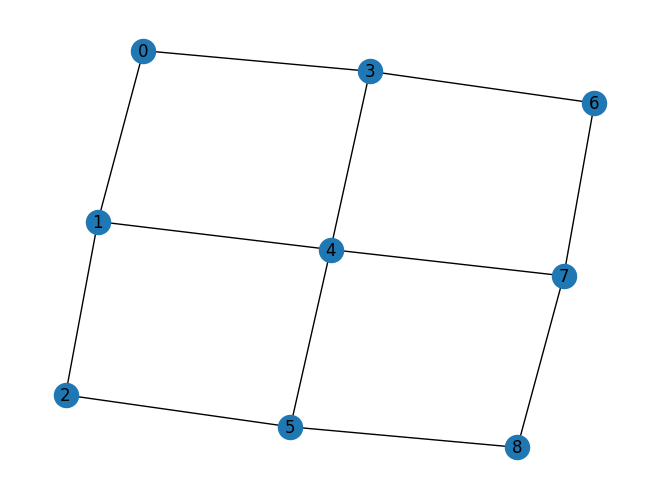

In [4]:
network = Network()
network.set_ready_topology("Grade", 3, 3)
network.draw()

In [5]:
print(f"Nodes: {list(network.nodes)}")
print(f"Edges: {list(network.edges)}")
print(f"Hosts: {list(network.hosts.keys())}")
print(f"Qubits in host 0: {len(network.get_host(0).memory)}")
print(f"EPRs on channel (0,1): {len(network.get_eprs_from_edge(0, 1))}")

Nodes: [0, 1, 2, 3, 4, 5, 6, 7, 8]
Edges: [(0, 3), (0, 1), (1, 4), (1, 2), (2, 5), (3, 6), (3, 4), (4, 7), (4, 5), (5, 8), (6, 7), (7, 8)]
Hosts: [0, 1, 2, 3, 4, 5, 6, 7, 8]
Qubits in host 0: 10
EPRs on channel (0,1): 10


---
## 4. Physical Layer

Create qubits, EPR pairs, and run the entanglement creation protocol.

In [6]:
alice = network.get_host(3)
bob = network.get_host(4)

result = network.physical.entanglement_creation_heralding_protocol(alice, bob)
print(f"\nECHP result: {result}")
print(f"Timeslot: {network.clock.now}")

2026-02-22 19:44:07,488: Timeslot 1: EPR pair created with fidelity 0.004421016525486998
2026-02-22 19:44:07,490: Timeslot 1: Entanglement creation protocol succeeded, but with low fidelity.



ECHP result: False
Timeslot: 1


---
## 5. Link Layer

Request entanglement between two hosts (with automatic retry and purification).

In [7]:
link_result = network.linklayer.request(1, 2)
print(f"\nLink layer request result: {link_result}")
print(f"Timeslot: {network.clock.now}")

2026-02-22 19:44:07,506: Timeslot 1: Entanglement attempt between 1 and 2.
2026-02-22 19:44:07,508: Timeslot 2: EPR pair created with fidelity 0.04892657189343761
2026-02-22 19:44:07,510: Timeslot 2: Entanglement creation protocol succeeded, but with low fidelity.
2026-02-22 19:44:07,511: Timeslot 2: Entanglement failed between 1 and 2 on attempt 1.
2026-02-22 19:44:07,512: Timeslot 2: Entanglement attempt between 1 and 2.
2026-02-22 19:44:07,513: Timeslot 3: EPR pair created with fidelity 0.3156229473084884
2026-02-22 19:44:07,513: Timeslot 3: Entanglement creation protocol succeeded, but with low fidelity.
2026-02-22 19:44:07,514: Timeslot 3: Entanglement failed between 1 and 2 on attempt 2.
2026-02-22 19:44:07,521: Purification type 1 was used.
2026-02-22 19:44:07,522: Timeslot 4: Purification failed on channel (1, 2) due to low fidelity after purification.



Link layer request result: False
Timeslot: 4


---
## 6. Network Layer

Perform entanglement swapping across a multi-hop route.

In [8]:
swap_result = network.networklayer.entanglement_swapping(0, 8)
print(f"\nEntanglement swapping result: {swap_result}")
print(f"Timeslot: {network.clock.now}")

2026-02-22 19:44:07,533: Timeslot 4: Looking for valid route between 0 and 8.
2026-02-22 19:44:07,535: Valid route found: [0, 3, 6, 7, 8]
2026-02-22 19:44:07,537: Timeslot 5: Performing Entanglement Swapping.
2026-02-22 19:44:07,538: EPR pair <quantumnet.quantum.epr.Epr object at 0x000001AEDA84D7C0> added to channel (0, 6).
2026-02-22 19:44:07,539: EPR pair <quantumnet.quantum.epr.Epr object at 0x000001AEC269FAA0> removed from channel (0, 3).
2026-02-22 19:44:07,540: EPR pair <quantumnet.quantum.epr.Epr object at 0x000001AEC26F51F0> removed from channel (3, 6).
2026-02-22 19:44:07,541: Timeslot 6: Performing Entanglement Swapping.
2026-02-22 19:44:07,542: EPR pair <quantumnet.quantum.epr.Epr object at 0x000001AEC26F51F0> added to channel (0, 7).
2026-02-22 19:44:07,543: EPR pair <quantumnet.quantum.epr.Epr object at 0x000001AEDA84D7C0> removed from channel (0, 6).
2026-02-22 19:44:07,544: EPR pair <quantumnet.quantum.epr.Epr object at 0x000001AEC26F6A50> removed from channel (6, 7).
20


Entanglement swapping result: False
Timeslot: 7


---
## 7. Transport Layer

Transmit qubits from Alice to Bob via teleportation.

In [9]:
transport_result = network.transportlayer.run_transport_layer(0, 8, 5)
print(f"\nTransport result: {transport_result}")
print(f"Timeslot: {network.clock.now}")

2026-02-22 19:44:07,555: Error: Alice has 10 qubits, but should have 5 qubits. Aborting transmission.



Transport result: False
Timeslot: 7


In [10]:
# Inspect teleported qubits
for info in network.transportlayer.get_teleported_qubits():
    print(f"Route {info['route']}: F_final={info['F_final']:.4f} (t={info['timeslot']})")

---
## 8. Application Layer — QKD E91

Run the E91 quantum key distribution protocol to generate a shared secret key.

In [11]:
shared_key = network.application_layer.run_app("QKD_E91", 0, 8, 5)
print(f"\nShared key: {shared_key}")
print(f"Timeslot: {network.clock.now}")

2026-02-22 19:44:07,575: Starting E91 protocol with 10 qubits.
2026-02-22 19:44:07,576: E91 qubits prepared at timeslot: 7
2026-02-22 19:44:07,577: Qubits prepared with key: [1, 0, 0, 1, 1, 1, 1, 0, 0, 0] and bases: [1, 1, 1, 1, 1, 1, 1, 0, 1, 1]
2026-02-22 19:44:07,578: Attempt 1 of qubit transmission between 0 and 8.
2026-02-22 19:44:07,579: Timeslot 7: Looking for valid route between 0 and 8.
2026-02-22 19:44:07,580: Valid route found: [0, 7, 8]
2026-02-22 19:44:07,581: Qubit teleportation from 0 to 8 on route [0, 7, 8] succeeded with final fidelity 0.17050157318276057.
2026-02-22 19:44:07,581: Timeslot 7: Looking for valid route between 0 and 8.
2026-02-22 19:44:07,582: Valid route found: [0, 7, 8]
2026-02-22 19:44:07,583: Qubit teleportation from 0 to 8 on route [0, 7, 8] succeeded with final fidelity 0.007932811732896982.
2026-02-22 19:44:07,585: Timeslot 7: Looking for valid route between 0 and 8.
2026-02-22 19:44:07,586: Valid route found: [0, 7, 8]
2026-02-22 19:44:07,587: Qub


Shared key: [0, 0, 0, 1, 0]
Timeslot: 28


---
## 9. Metrics and Summary

Collect and display all simulation metrics.

In [12]:
print(f"Total timeslots: {network.clock.now}")
print(f"Total used EPRs: {network.get_total_used_eprs()}")
print(f"Total used qubits: {network.get_total_used_qubits()}")
print(f"Link layer avg fidelity: {network.linklayer.avg_fidelity_on_linklayer():.6f}")
print(f"Transport layer avg fidelity: {network.transportlayer.avg_fidelity_on_transportlayer():.6f}")
print(f"Average route size: {network.networklayer.get_avg_size_routes():.2f} hops")

2026-02-22 19:44:07,714: EPRs used in layer PhysicalLayer: 3
2026-02-22 19:44:07,715: EPRs used in layer LinkLayer: 2
2026-02-22 19:44:07,715: EPRs used in layer NetworkLayer: 2
2026-02-22 19:44:07,716: Qubits used in layer PhysicalLayer: 22
2026-02-22 19:44:07,717: Qubits used in layer LinkLayer: 4
2026-02-22 19:44:07,718: Qubits used in layer TransportLayer: 26
2026-02-22 19:44:07,719: Qubits used in layer ApplicationLayer: 26
2026-02-22 19:44:07,720: Total EPRs created in the link layer: 3
2026-02-22 19:44:07,721: Total fidelity of EPRs created in the link layer: 0.02607677469808308
2026-02-22 19:44:07,722: The average fidelity of EPRs created in the link layer is 0.00869225823269436
2026-02-22 19:44:07,723: Fidelity of qubit used from 0 to 8: 0.17050157318276057
2026-02-22 19:44:07,724: Fidelity of qubit used from 0 to 8: 0.007932811732896982
2026-02-22 19:44:07,726: Fidelity of qubit used from 0 to 8: 0.03400099159695565
2026-02-22 19:44:07,727: Fidelity of qubit used from 0 to 8:

Total timeslots: 28
Total used EPRs: 7
Total used qubits: 78
Link layer avg fidelity: 0.008692


2026-02-22 19:44:07,734: Fidelity of qubit used from 0 to 8: 0.0483318253307962
2026-02-22 19:44:07,735: Fidelity of qubit used from 0 to 8: 0.0022307740635647165
2026-02-22 19:44:07,735: Fidelity of qubit used from 0 to 8: 0.15285890256840629
2026-02-22 19:44:07,736: Fidelity of qubit used from 0 to 8: 0.058906907357524844
2026-02-22 19:44:07,736: Fidelity of qubit used from 0 to 8: 0.01838155469306247
2026-02-22 19:44:07,737: Fidelity of qubit used from 0 to 8: 0.12218960463277564
2026-02-22 19:44:07,737: Fidelity of qubit used from 0 to 8: 0.10181107891596841
2026-02-22 19:44:07,738: Fidelity of qubit used from 0 to 8: 0.008179564093813966
2026-02-22 19:44:07,740: Fidelity of qubit used from 0 to 8: 0.005689296330399312
2026-02-22 19:44:07,740: Fidelity of qubit used from 0 to 8: 0.06450926269115607
2026-02-22 19:44:07,741: Fidelity of qubit used from 0 to 8: 0.03424704042943713
2026-02-22 19:44:07,741: Fidelity of qubit used from 0 to 8: 0.012738912519367679
2026-02-22 19:44:07,742

Transport layer avg fidelity: 0.072392
Average route size: 4.00 hops


In [13]:
# Export metrics using get_metrics
metrics = network.get_metrics(output_type="variable")
for name, value in metrics.items():
    print(f"{name}: {value}")

2026-02-22 19:44:07,753: EPRs used in layer PhysicalLayer: 3
2026-02-22 19:44:07,754: EPRs used in layer LinkLayer: 2
2026-02-22 19:44:07,755: EPRs used in layer NetworkLayer: 2
2026-02-22 19:44:07,756: Qubits used in layer PhysicalLayer: 22
2026-02-22 19:44:07,757: Qubits used in layer LinkLayer: 4
2026-02-22 19:44:07,759: Qubits used in layer TransportLayer: 26
2026-02-22 19:44:07,759: Qubits used in layer ApplicationLayer: 26
2026-02-22 19:44:07,761: Fidelity of qubit used from 0 to 8: 0.17050157318276057
2026-02-22 19:44:07,761: Fidelity of qubit used from 0 to 8: 0.007932811732896982
2026-02-22 19:44:07,761: Fidelity of qubit used from 0 to 8: 0.03400099159695565
2026-02-22 19:44:07,762: Fidelity of qubit used from 0 to 8: 0.06731870005894289
2026-02-22 19:44:07,762: Fidelity of qubit used from 0 to 8: 0.0657132153674039
2026-02-22 19:44:07,763: Fidelity of qubit used from 0 to 8: 0.21458225192559943
2026-02-22 19:44:07,765: Fidelity of qubit used from 0 to 8: 0.12402799031722639


Total Timeslot: 28
Used EPRs: 7
Used Qubits: 78
Transport Layer Fidelity: 0.07239205118621476
Link Layer Fidelity: 0.00869225823269436
Average Routes: 4.0


## 10. Clock Event History

The clock records every event emitted during the simulation.

In [14]:
for entry in network.clock.history[:20]:  # show first 20 events
    print(entry)

{'timeslot': 0, 'event': 'qubit_created', 'host_id': 0, 'qubit_id': 0}
{'timeslot': 0, 'event': 'qubit_created', 'host_id': 0, 'qubit_id': 1}
{'timeslot': 0, 'event': 'qubit_created', 'host_id': 0, 'qubit_id': 2}
{'timeslot': 0, 'event': 'qubit_created', 'host_id': 0, 'qubit_id': 3}
{'timeslot': 0, 'event': 'qubit_created', 'host_id': 0, 'qubit_id': 4}
{'timeslot': 0, 'event': 'qubit_created', 'host_id': 0, 'qubit_id': 5}
{'timeslot': 0, 'event': 'qubit_created', 'host_id': 0, 'qubit_id': 6}
{'timeslot': 0, 'event': 'qubit_created', 'host_id': 0, 'qubit_id': 7}
{'timeslot': 0, 'event': 'qubit_created', 'host_id': 0, 'qubit_id': 8}
{'timeslot': 0, 'event': 'qubit_created', 'host_id': 0, 'qubit_id': 9}
{'timeslot': 0, 'event': 'qubit_created', 'host_id': 1, 'qubit_id': 10}
{'timeslot': 0, 'event': 'qubit_created', 'host_id': 1, 'qubit_id': 11}
{'timeslot': 0, 'event': 'qubit_created', 'host_id': 1, 'qubit_id': 12}
{'timeslot': 0, 'event': 'qubit_created', 'host_id': 1, 'qubit_id': 13}
{'

## 11. Qubit Creation Timeline

In [15]:
network.display_all_qubit_timeslots()

2026-02-22 19:44:07,807: Qubit 0 was created at timeslot 0 in layer Physical Layer
2026-02-22 19:44:07,809: Qubit 1 was created at timeslot 0 in layer Physical Layer
2026-02-22 19:44:07,810: Qubit 2 was created at timeslot 0 in layer Physical Layer
2026-02-22 19:44:07,811: Qubit 3 was created at timeslot 0 in layer Physical Layer
2026-02-22 19:44:07,812: Qubit 4 was created at timeslot 0 in layer Physical Layer
2026-02-22 19:44:07,813: Qubit 5 was created at timeslot 0 in layer Physical Layer
2026-02-22 19:44:07,814: Qubit 6 was created at timeslot 0 in layer Physical Layer
2026-02-22 19:44:07,815: Qubit 7 was created at timeslot 0 in layer Physical Layer
2026-02-22 19:44:07,815: Qubit 8 was created at timeslot 0 in layer Physical Layer
2026-02-22 19:44:07,816: Qubit 9 was created at timeslot 0 in layer Physical Layer
2026-02-22 19:44:07,816: Qubit 10 was created at timeslot 0 in layer Physical Layer
2026-02-22 19:44:07,817: Qubit 11 was created at timeslot 0 in layer Physical Layer
20